Exercise 1

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"]


In [ ]:
df = pd.read_csv("/content/iris.data", names=columns)

In [ ]:
df["class"] = df["class"].astype("category").cat.codes

In [ ]:
df

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
import seaborn as sns

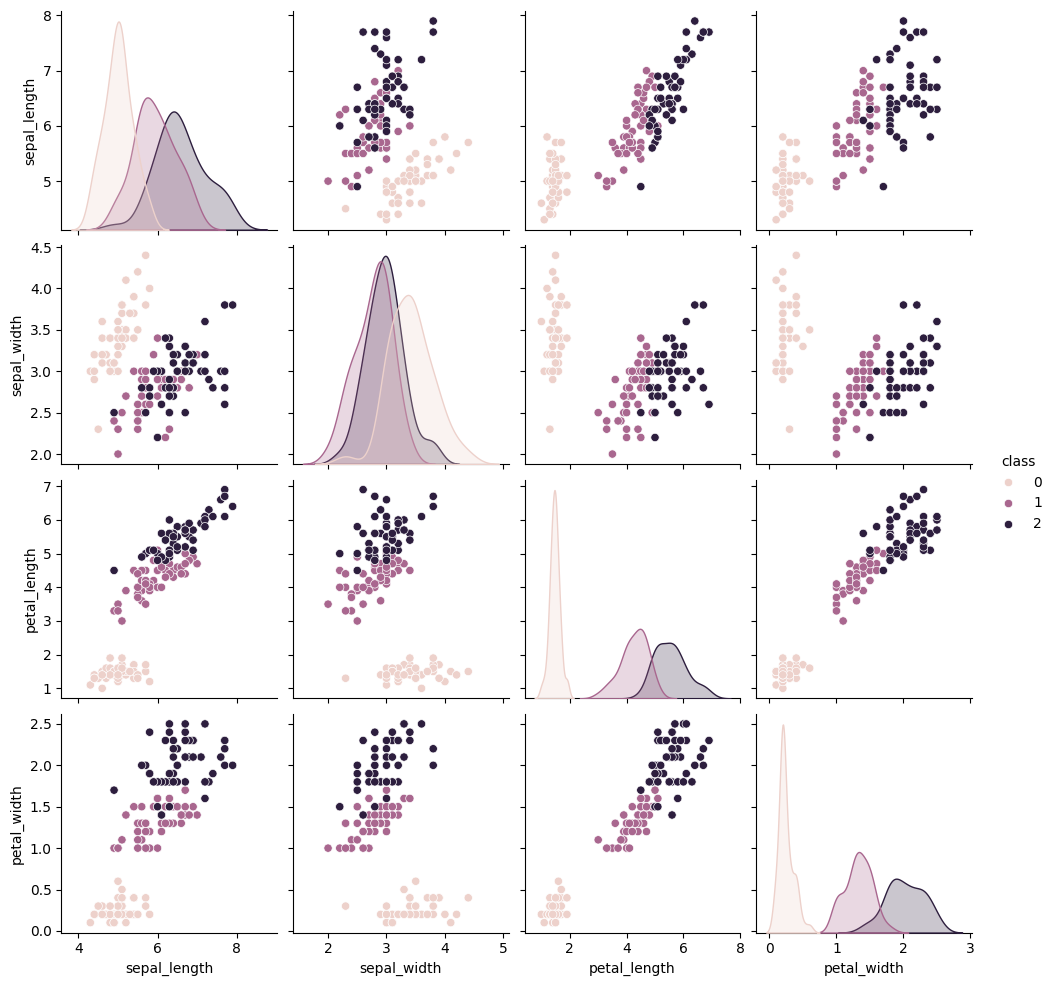

In [ ]:
import matplotlib.pyplot as plt
sns.pairplot(df, hue='class')
plt.show()

In [ ]:
X = df.drop("class", axis=1)
y = df["class"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("F1 Score:", f1_score(y_test, y_pred, average="macro"))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [ ]:
from sklearn.model_selection import StratifiedKFold
print("StratifiedKFold imported successfully.")

StratifiedKFold imported successfully.


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

print("StratifiedKFold initialized and metric lists created.")

StratifiedKFold initialized and metric lists created.


In [ ]:
for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    model_fold = LogisticRegression(max_iter=200)
    model_fold.fit(X_train_fold, y_train_fold)
    y_pred_fold = model_fold.predict(X_test_fold)

    accuracy_scores.append(accuracy_score(y_test_fold, y_pred_fold))
    precision_scores.append(precision_score(y_test_fold, y_pred_fold, average="macro"))
    recall_scores.append(recall_score(y_test_fold, y_pred_fold, average="macro"))
    f1_scores.append(f1_score(y_test_fold, y_pred_fold, average="macro"))

print("Cross-validation completed. Metrics calculated for all folds.")

Cross-validation completed. Metrics calculated for all folds.


In [ ]:
import numpy as np

mean_accuracy = np.mean(accuracy_scores)
std_accuracy = np.std(accuracy_scores)

mean_precision = np.mean(precision_scores)
std_precision = np.std(precision_scores)

mean_recall = np.mean(recall_scores)
std_recall = np.std(recall_scores)

mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)

print(f"Mean Accuracy: {mean_accuracy:.4f} (Std: {std_accuracy:.4f})")
print(f"Mean Precision: {mean_precision:.4f} (Std: {std_precision:.4f})")
print(f"Mean Recall: {mean_recall:.4f} (Std: {std_recall:.4f})")
print(f"Mean F1 Score: {mean_f1:.4f} (Std: {std_f1:.4f})")

Mean Accuracy: 0.9667 (Std: 0.0298)
Mean Precision: 0.9695 (Std: 0.0276)
Mean Recall: 0.9667 (Std: 0.0298)
Mean F1 Score: 0.9665 (Std: 0.0300)


Exercise 2

In [ ]:
df = pd.read_csv('/content/Wholesale customers data.csv')
print("First 5 rows of the DataFrame:")
print(df.head())

print("\nConcise summary of the DataFrame:")
df.info()

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nDescriptive statistics of the DataFrame:")
print(df.describe())

First 5 rows of the DataFrame:
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185

Concise summary of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    in

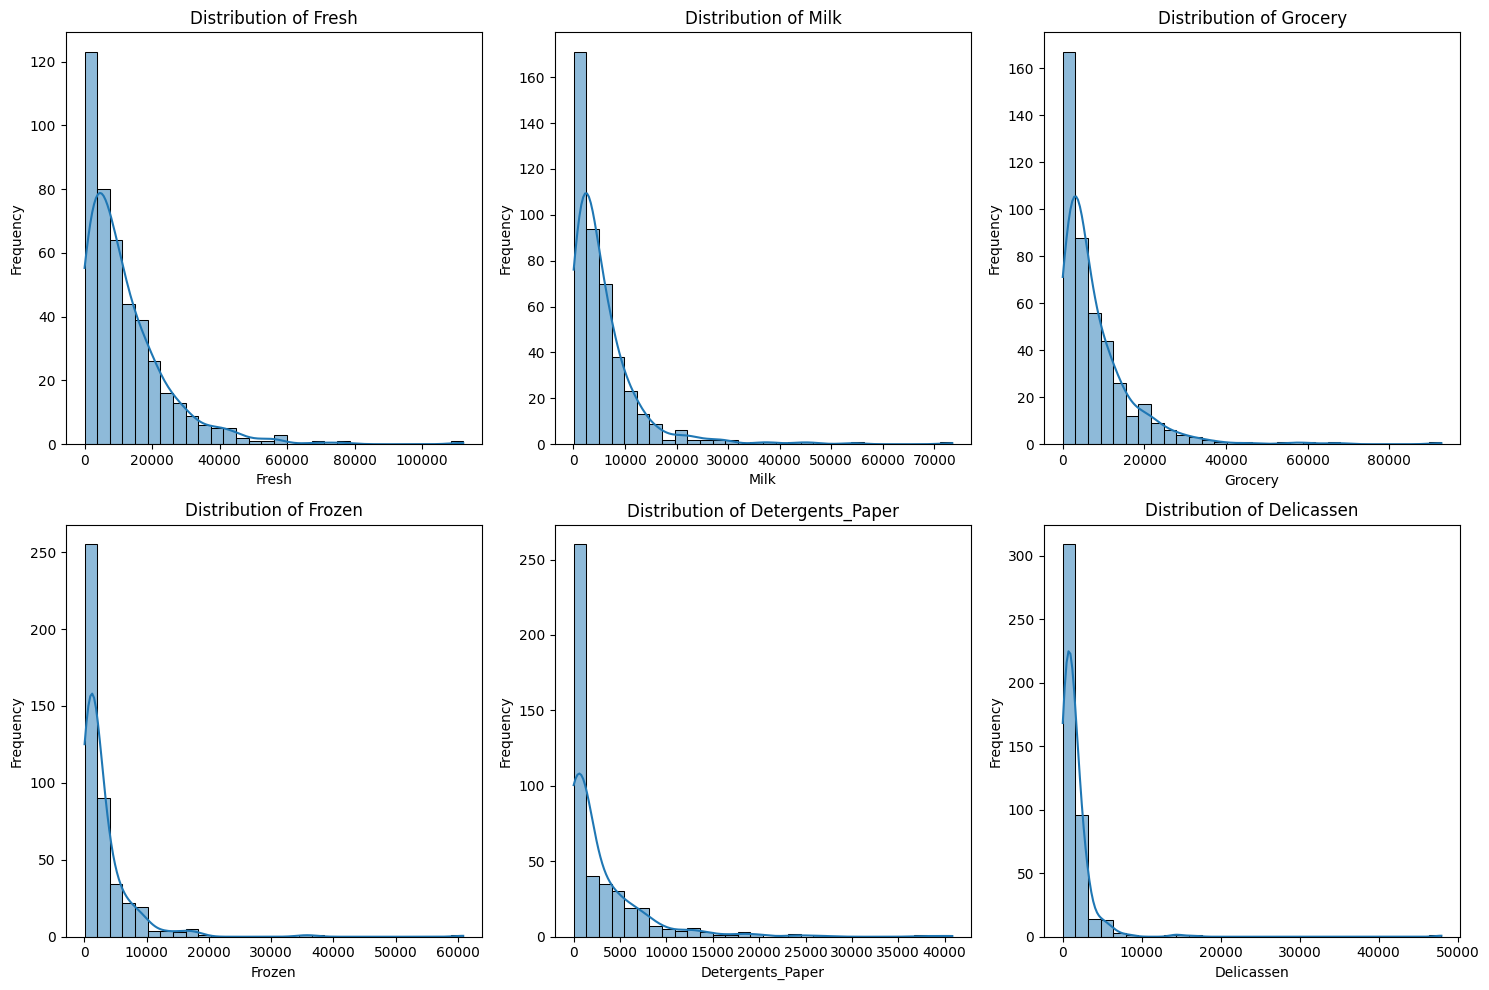

Histograms for spending categories generated.


In [ ]:
spending_categories = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

plt.figure(figsize=(15, 10))
for i, col in enumerate(spending_categories):
    plt.subplot(2, 3, i + 1) # Arrange in 2 rows, 3 columns
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Histograms for spending categories generated.")

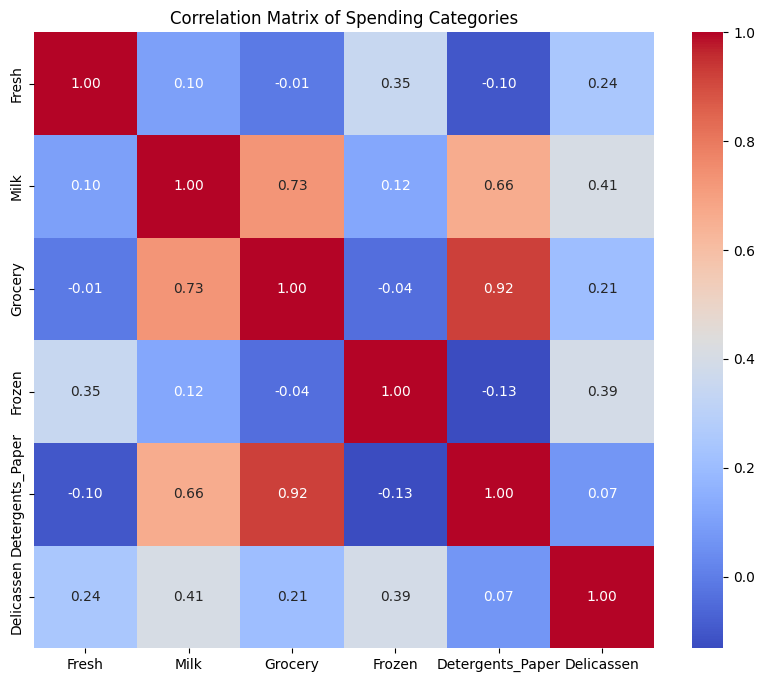

Correlation matrix heatmap generated.


In [ ]:
correlation_matrix = df[spending_categories].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Spending Categories')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

spending_categories = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
X_spending = df[spending_categories]

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit and transform the data
scaled_features = scaler.fit_transform(X_spending)

# Print the first few rows of the scaled featuresroc_curve(Y_test,y_prob[:,1])
print("First 5 rows of scaled features:")
print(scaled_features[:5])

First 5 rows of scaled features:
[[ 0.05293319  0.52356777 -0.04111489 -0.58936716 -0.04356873 -0.06633906]
 [-0.39130197  0.54445767  0.17031835 -0.27013618  0.08640684  0.08915105]
 [-0.44702926  0.40853771 -0.0281571  -0.13753572  0.13323164  2.24329255]
 [ 0.10011141 -0.62401993 -0.3929769   0.6871443  -0.49858822  0.09341105]
 [ 0.84023948 -0.05239645 -0.07935618  0.17385884 -0.23191782  1.29934689]]


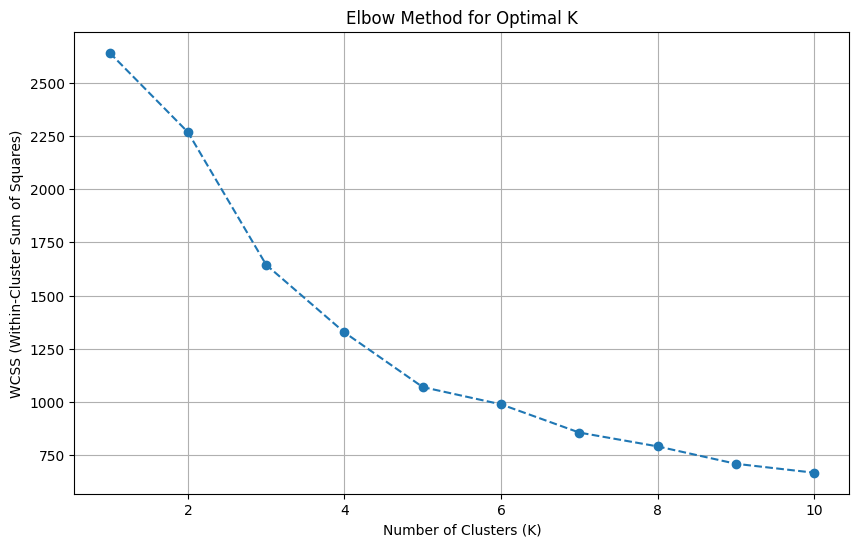

Elbow method plot generated.


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
# Iterate through a range of cluster numbers (e.g., from 1 to 10 or 15)
for i in range(1, 11): # Commonly, 10 or 15 clusters are sufficient for initial elbow method
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

print("Elbow method plot generated.")

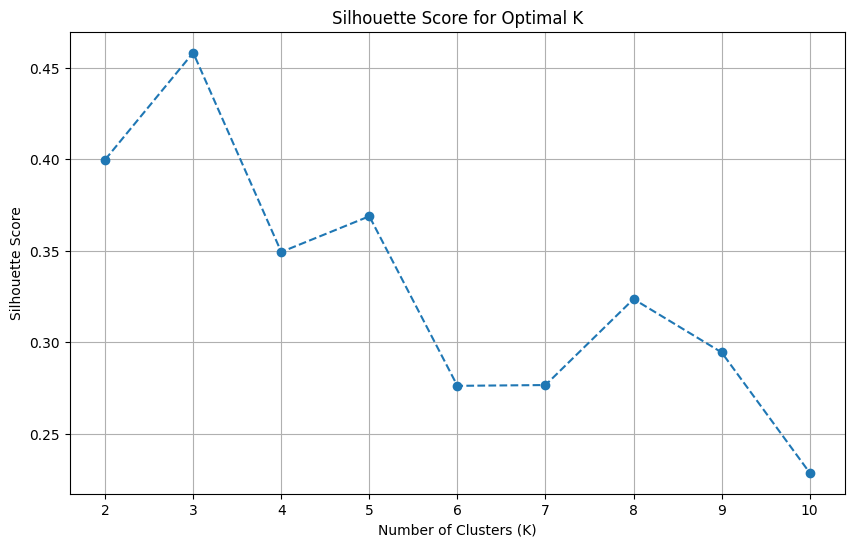

Silhouette score plot generated.


In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

# Iterate through a range of cluster numbers (e.g., from 2 to 10 or 15)
# Silhouette score is not defined for k=1
for i in range(2, 11): # Using range from 2 to 10 for consistency with WCSS plot range
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(scaled_features)
    labels = kmeans.predict(scaled_features)
    silhouette_scores.append(silhouette_score(scaled_features, labels))

# Plot the Silhouette Score graph
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

print("Silhouette score plot generated.")

In [ ]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init='auto')
kmeans.fit(scaled_features)

cluster_labels = kmeans.predict(scaled_features)
df['Cluster'] = cluster_labels

print("First 5 rows of DataFrame with assigned clusters:")
print(df.head())

First 5 rows of DataFrame with assigned clusters:
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669  9656     7561     214              2674   
1        2       3   7057  9810     9568    1762              3293   
2        2       3   6353  8808     7684    2405              3516   
3        1       3  13265  1196     4221    6404               507   
4        2       3  22615  5410     7198    3915              1777   

   Delicassen  Cluster  
0        1338        0  
1        1776        0  
2        7844        0  
3        1788        0  
4        5185        1  


In [ ]:
from sklearn.decomposition import PCA

# Instantiate PCA with 2 components
pca = PCA(n_components=2)

# Fit PCA to the scaled features and transform the data
pca_components = pca.fit_transform(scaled_features)

# Print the shape of the transformed data
print(f"Shape of PCA components: {pca_components.shape}")

# Print the explained variance ratio
print(f"Explained variance ratio of PCA components: {pca.explained_variance_ratio_}")
print(f"Total explained variance by 2 components: {pca.explained_variance_ratio_.sum():.2f}")

Shape of PCA components: (440, 2)
Explained variance ratio of PCA components: [0.44082893 0.283764  ]
Total explained variance by 2 components: 0.72


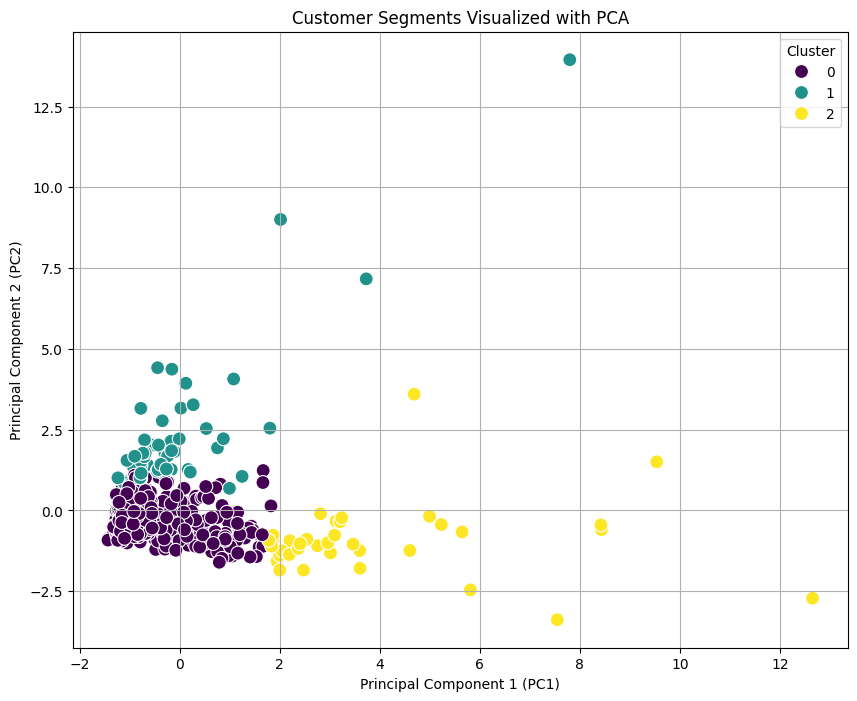

Scatter plot of customer segments with PCA generated.


In [ ]:
pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster']

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', s=100)
plt.title('Customer Segments Visualized with PCA')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

print("Scatter plot of customer segments with PCA generated.")

In [ ]:
spending_categories = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

# Group by 'Cluster' and calculate the mean for each spending category
cluster_spending_patterns = df.groupby('Cluster')[spending_categories].mean()

# Print the cluster spending patterns
print("Mean spending patterns per cluster:")
print(cluster_spending_patterns)

Mean spending patterns per cluster:
                Fresh          Milk       Grocery       Frozen  \
Cluster                                                          
0         8935.500000   4228.528571   5848.034286  2167.231429   
1        34540.113208   5860.358491   6122.622642  9841.735849   
2         8704.864865  20534.405405  30466.243243  1932.621622   

         Detergents_Paper   Delicassen  
Cluster                                 
0             1913.605714  1102.120000  
1              981.471698  3664.245283  
2            14758.837838  2459.351351  
